PCA on general dataset to allow for TF-IDF models to be ran

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv('General_Dataset_TF-IDF_vectorised_tweets.csv')
data.head

<bound method NDFrame.head of        aaaaa  aaaaaaaa  aaaaahhhhhmmmm  aaallll  aaand  aabramz  aam  aap  \
0        0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   
1        0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   
2        0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   
3        0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   
4        0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   
...      ...       ...             ...      ...    ...      ...  ...  ...   
11891    0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   
11892    0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   
11893    0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   
11894    0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   
11895    0.0       0.0             0.0      0.0    0.0      0.0  0.0  0.0   

       aapl  aaron  ...  zyrszbijgl  zzchzufv

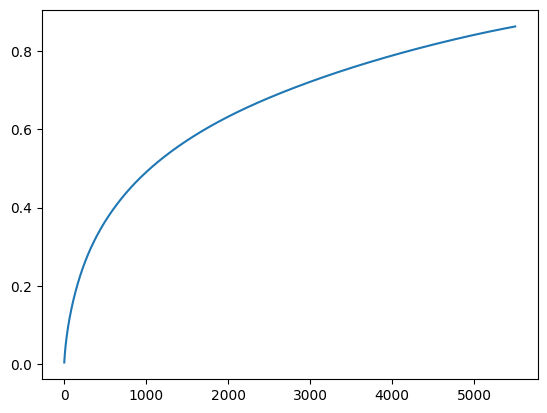

In [3]:

from sklearn.decomposition import PCA
data= data.drop(columns='unit_id')
#Fit the PCA model to the TF-IDF datapca
pca2 = PCA(n_components=5500)
pca_result = pca2.fit_transform(data)  
explained_variance = pca2.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
# Plot cumulative variance to help you decide
#plt.xlabel('Principal component index')
#plt.ylabel('Cumulative variance explained')
plt.plot(cumulative_variance)

In [4]:
explained_variance = pca2.explained_variance_ratio_

x=5500
variance_explained_by_x_components = np.sum(explained_variance[:x])

print(f"Variance explained by the first {x} components: {variance_explained_by_x_components:.2f}")

Variance explained by the first 5500 components: 0.86


In [5]:
##saving pca_result as dataframe
pca_tfidf_tweet_general = pd.DataFrame(data=pca_result)
pca_tfidf_tweet_general.head

<bound method NDFrame.head of            0         1         2         3         4         5         6     \
0      0.034115 -0.046767 -0.039865 -0.003487 -0.012492 -0.006301 -0.037440   
1      0.050726 -0.072829 -0.058526 -0.017875 -0.012849 -0.024574  0.006569   
2     -0.030015  0.017335 -0.003327 -0.024954  0.000792 -0.011888  0.056547   
3      0.012814 -0.046015 -0.010104 -0.012543 -0.002840  0.004301 -0.011904   
4     -0.003268 -0.002683 -0.013059 -0.024007 -0.013103 -0.004608 -0.018774   
...         ...       ...       ...       ...       ...       ...       ...   
11891 -0.037406 -0.037450  0.115427  0.002286 -0.022621  0.017008 -0.050465   
11892 -0.049555  0.069136 -0.038150  0.082204 -0.040593  0.036645  0.012237   
11893 -0.096096  0.083008  0.086871 -0.038143 -0.006421 -0.063157  0.035311   
11894 -0.030930  0.039067  0.003294 -0.058537 -0.003780 -0.025013  0.016239   
11895  0.019606  0.078266  0.017187 -0.038443  0.081899 -0.002936 -0.049125   

           7         

In [6]:
pca_tfidf_tweet_general.to_csv('pca_tfidf_tweets_dataset2', index=False)